In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import torch

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
def plot_mean_data(data):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cohs_sorted = sorted(data["coherence"].unique())

    # Psychometric function
    p_upper = []
    for coh in cohs_sorted:
        subset = data[data["coherence"] == coh].dropna()
        p_upper.append((subset["choice"] == 1).mean())

    axes[0].plot(cohs_sorted, p_upper, "o-", color="steelblue")
    axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_xlabel("Coherence")
    axes[0].set_ylabel("P(upper boundary)")
    axes[0].set_title("Psychometric Function")
    axes[0].set_ylim(0, 1)

    # Chronometric function
    mean_rt  = []
    sem_rt   = []
    for coh in cohs_sorted:
        subset = data[data["coherence"] == coh].dropna()
        mean_rt.append(subset["rt"].mean())
        sem_rt.append(subset["rt"].sem())

    axes[1].errorbar(cohs_sorted, mean_rt, yerr=sem_rt, fmt="o-", color="tomato", capsize=4)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_xlabel("Coherence")
    axes[1].set_ylabel("Mean RT (s)")
    axes[1].set_title("Chronometric Function")

    plt.tight_layout()
    plt.show()

# for each coherence plot histogram of RTs for choice 0 and choice 1
def plot_raw_data(data):

    fig, axes = plt.subplots(len(data["coherence"].unique()), 1, figsize=(8, 3 * len(data["coherence"].unique())))

    for ax, coh in zip(axes, sorted(data["coherence"].unique())):
        subset = data[data["coherence"] == coh]
        ax.hist(subset[subset["choice"] == 0]["rt"], bins=20, alpha=0.5, label="choice 0", color="steelblue")
        ax.hist(subset[subset["choice"] == 1]["rt"], bins=20, alpha=0.5, label="choice 1", color="tomato")
        ax.set_title(f"Coherence: {coh:+.2f}")
        ax.set_xlabel("RT (s)")
        ax.set_ylabel("Count")
        ax.set_xlim(0, data["rt"].max() + 0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Generate Data

In [3]:
from src.ddm.ddm  import DDMParams, DriftDiffusionSimulatorCUDA, ParamSpec, DecisionModel

COHERENCES     = np.array([-0.50, -0.18, -0.09, 0.0, 0.09, 0.18, 0.50]).round(2)
TRIALS_PER_COH = 150
MAX_DURATION     = 3.0
DT               = 0.001

def make_stimulus() -> np.ndarray:
    n_tp = int(MAX_DURATION / DT)
    coh  = np.repeat(COHERENCES, TRIALS_PER_COH)
    return np.tile(coh.reshape(-1, 1), (1, n_tp)).astype(np.float32)

def generate_data(params: DDMParams, trials=TRIALS_PER_COH, max_duration=MAX_DURATION) -> pd.DataFrame:

    stimulus=make_stimulus()

    sim = DriftDiffusionSimulatorCUDA(device="cuda")

    coherences = np.mean(stimulus, axis=1)  # get coherence for each trial (constant across time)
    rt, choice = sim.simulate_trials(stimulus, params=params)

    return pd.DataFrame({
            "coherence": coherences,
            "rt": rt,
            "choice": choice,
        }), stimulus


In [4]:
from src.ddm.ddm_simple import DriftDiffusionSimulatorCUDA as SimpleCUDA, DEFAULT_PARAMS, validate_params

def generate_data_simple(params: dict = None, trials=TRIALS_PER_COH, max_duration=MAX_DURATION):
    """Like generate_data() but uses the ddm_simple dict-based API."""
    if params is None:
        params = dict(DEFAULT_PARAMS)
    validate_params(params)

    stimulus   = make_stimulus()
    sim        = SimpleCUDA(device="cuda")
    rt, choice = sim.simulate_trials(stimulus, params)

    # Use stimulus[:, 0] directly (float32) to avoid np.mean upcasting to
    # float64, which causes == comparisons to silently miss coherence bins.
    coherences = stimulus[:, 0]

    return pd.DataFrame({"coherence": coherences, "rt": rt, "choice": choice}), stimulus

In [5]:
p = DDMParams()          # all defaults
p.a            = 1    # boundary separation
p.z            = 0.5   # starting point (0-1, fraction of a)
p.ndt          = 0.25   # non-decision time (seconds)
p.drift_gain   = 8.0    # scales coherence into drift rate
p.drift_offset = 0    # baseline drift (prior bias)
p.variance     = 1.0    # noise variance -- ALWAYS fix at 1.0 (see note)
p.leak_rate    = 0.08   # leaky accumulation rate (0 = no leak)
p.time_constant = 0.5   # urgency signal strength (0 = no urgency)
p.validate()


# data, stimulus = generate_data(p)
data, stimulus = generate_data_simple()  # using the simple dict-based API

# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()

# print(summary)

# plot_mean_data(data)
# plot_raw_data(data)

INFO:src.ddm.ddm_simple:Using device: cpu


# Recovery Trial

In [6]:
from src.ddm.ddm import DDMParams, ParamSpec, DecisionModel, SimResult
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [7]:
PARAM_SPECS: dict[str, ParamSpec] = {
    "ndt":           ParamSpec(0.2,  (0.1,   1)),
    "a":             ParamSpec(2.0,  (0.8,   6.0)),
    "z":             ParamSpec(0.5,  (0.1,   0.9)),
    "drift_gain":    ParamSpec(7.0,  (1.0,  10.0)),
    "drift_offset":  ParamSpec(0.0,  (-5.0,  5.0)),
    "variance":      ParamSpec(1.0,  (0.1,   5.0)),
    "leak_rate":     ParamSpec(0.1,  (0.0,   0.5)),
    "time_constant": ParamSpec(0.0,  (-3.0,  3.0)),
}

fixed_params = ["variance"]
free_specs = {k: v for k, v in PARAM_SPECS.items() if k not in fixed_params}


In [8]:
# class Model(DecisionModel):
#     def __init__(self, device=device):
#         super().__init__(device=str(device))

#     @property
#     def param_specs(self) -> dict[str, ParamSpec]:
#         return free_specs  # the dict already defined in the notebook

#     def _build_params(self, values: np.ndarray, condition_idx=None) -> DDMParams:
#         p = DDMParams()
#         for (name, spec), val in zip(free_specs.items(), values):
#             setattr(p, name, val)
#         p.variance = 1.0  # fixed
#         p.validate()
#         return p

#     def _objective_function(self, values, data, stimulus, n_reps, seed, l1_weight):
#         try:
#             params = self._build_params(values)
#         except ValueError:
#             return 1e6

#         result = self._simulate_condition(stimulus, params, n_reps)
#         if not result.ok:
#             return 1e6

#         nllh = self.likelihood_calc.calculate_likelihood(
#             result.rt, result.choice,
#             data["rt"].values, data["choice"].values,
#             result.coherence, data["coherence"].values,
#         )
#         # L1 regularisation on drift_offset (keeps it near zero)
#         l1 = l1_weight * abs(values[list(free_specs).index("drift_offset")])
#         return nllh + l1



# model = Model(device=device)
# result = model.fit(
#     data={"rt": data["rt"], "choice": data["choice"], "coherence": data["coherence"]},
#     stimulus=stimulus,
#     max_iterations=100,
#     n_reps=5,
#     l1_weight=0,
# )
# print(result["parameters"])

### DDM Simple

In [9]:
from src.ddm.ddm_simple import DecisionModel, ParamSpec, DEFAULT_PARAMS, validate_params

class SimpleModel(DecisionModel):

    @property
    def param_specs(self) -> dict[str, ParamSpec]:
        return {
            "ndt":           ParamSpec(0.2,  (0.1,  1.0)),
            "a":             ParamSpec(2.0,  (0.8,  6.0)),
            "z":             ParamSpec(0.5,  (0.1,  0.9)),
            "drift_gain":    ParamSpec(7.0,  (1.0, 10.0)),
            "drift_offset":  ParamSpec(0.0,  (-5.0, 5.0)),
            "leak_rate":     ParamSpec(0.1,  (0.0,  1.0)),
            "time_constant": ParamSpec(0.0,  (-3.0, 3.0)),
        }

    def _build_params(self, values: np.ndarray, condition_idx=None) -> dict:
        p = dict(DEFAULT_PARAMS)
        for key, val in zip(self.param_specs.keys(), values):
            p[key] = val
        p["variance"] = 1.0  # always fixed
        validate_params(p)
        return p

    def _objective_function(self, values, data, stimulus, n_reps, seed, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6
        result = self._simulate_condition(stimulus, params, n_reps)
        if result is None:
            return 1e6
        return self.likelihood_calc.calculate_likelihood(
            result["rt"], result["choice"],
            np.asarray(data["rt"]), np.asarray(data["choice"]),
            result["coherence"], np.asarray(data["coherence"]),
        )


In [10]:
simple_model_cuda = SimpleModel(device='cuda')
result_cuda = simple_model_cuda.fit(
    data={"rt": data["rt"], "choice": data["choice"], "coherence": data["coherence"]},
    stimulus=stimulus,
    max_iterations=100,
    n_reps=5,
    l1_weight=0,
)

INFO:src.ddm.ddm_simple:Initialized SimpleModel | device=CPU
INFO:src.ddm.ddm_simple:Starting optimisation (SimpleModel)...
INFO:src.ddm.ddm_simple:Iter   1 | NLL=994.9846 | convergence=0.0349 | ndt=0.1661  a=2.4128  z=0.3537  drift_gain=3.3757  drift_offset=0.9943  leak_rate=0.6659  time_constant=0.2961
INFO:src.ddm.ddm_simple:Iter   2 | NLL=143.1600 | convergence=0.0287 | ndt=0.1139  a=2.6187  z=0.5508  drift_gain=7.9832  drift_offset=-0.4902  leak_rate=0.1721  time_constant=0.3748
INFO:src.ddm.ddm_simple:Iter   3 | NLL=143.1600 | convergence=0.0247 | ndt=0.1139  a=2.6187  z=0.5508  drift_gain=7.9832  drift_offset=-0.4902  leak_rate=0.1721  time_constant=0.3748
INFO:src.ddm.ddm_simple:Iter   4 | NLL=143.1600 | convergence=0.0203 | ndt=0.1139  a=2.6187  z=0.5508  drift_gain=7.9832  drift_offset=-0.4902  leak_rate=0.1721  time_constant=0.3748
INFO:src.ddm.ddm_simple:Iter   5 | NLL=143.1600 | convergence=0.0180 | ndt=0.1139  a=2.6187  z=0.5508  drift_gain=7.9832  drift_offset=-0.4902  l

# plot model simulations

In [11]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    cohs = sorted(coherences if coherences is not None else data["coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    return fig

In [17]:
def model_comparison():
    # Use _build_params so the simulated params exactly match what was optimised
    params = []
    for k in simple_model_cuda.param_specs:
        if k == "leak_rate":
            params.append(0.08)
        elif k == "time_constant":
            params.append(0.5)
        else:
            params.append(result_cuda["parameters"][k])

    fitted_params = simple_model_cuda._build_params(params)



    sim = simple_model_cuda.simulate(stimulus, params=fitted_params, n_reps=10, seed=0)
    return pd.DataFrame(sim)


## Likelihood Calculator

In [18]:
from src.ddm.ddm_simple import LikelihoodCalculator


# calculate likelihoods for both models and original data
sim_data_cuda = model_comparison()
data = data.dropna(subset=["rt", "choice"])


llh_calculator = LikelihoodCalculator()
llh_cuda = llh_calculator.calculate_likelihood(
    sim_data_cuda["rt"].values, sim_data_cuda["choice"].values,
    data["rt"].values, data["choice"].values,
    sim_data_cuda["coherence"].values, data["coherence"].values,
)

# calculate likelihood for original data against itself (sanity check, should be close to 0)
llh_data = llh_calculator.calculate_likelihood(
    data["rt"].values, data["choice"].values,
    data["rt"].values, data["choice"].values,
    data["coherence"].values, data["coherence"].values,
)

print(f"Likelihoods:\n  CUDA fit - model: {result_cuda['likelihood']:.1f}, likelihood_calculator {llh_cuda:.1f}")

print(f"Data vs itself: {llh_data:.1f}")

Likelihoods:
  CUDA fit - model: 24.4, likelihood_calculator 148.9
Data vs itself: 0.0


In [ ]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["coherence"] = data["coherence"].round(2)
    sim["coherence"]  = sim["coherence"].round(2)

    cohs = sorted(coherences if coherences is not None else data["coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    return fig

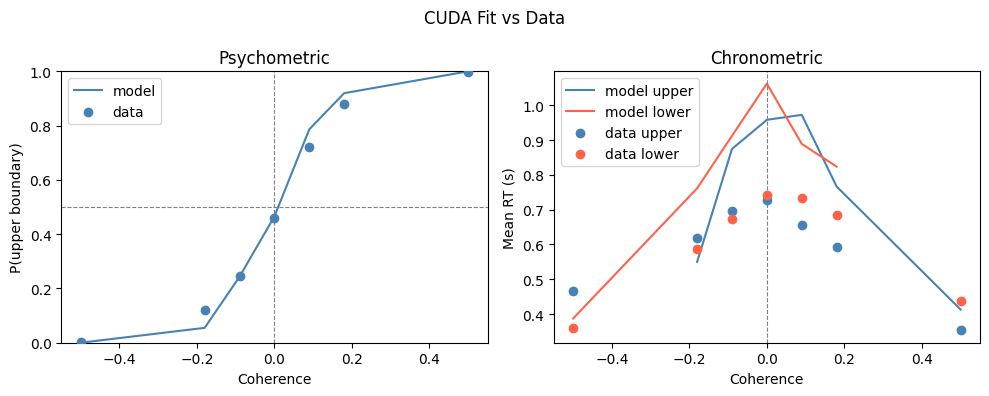

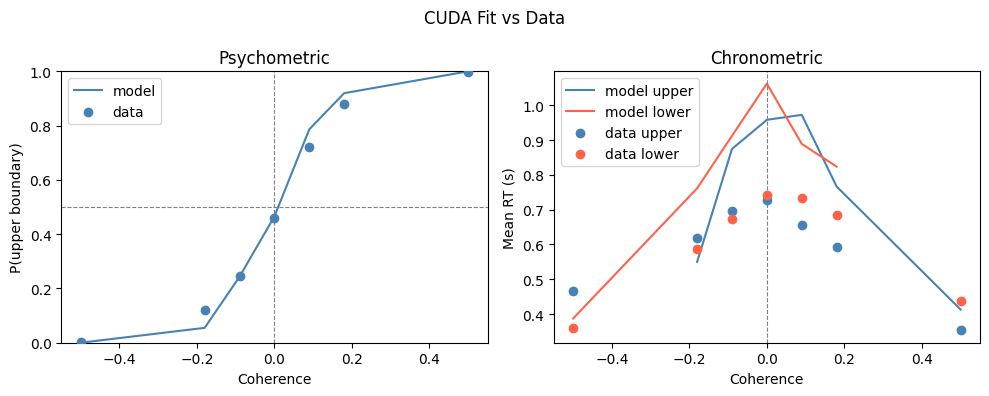

In [20]:
plot_ddm_fit(sim_data_cuda, data, title="CUDA Fit vs Data")